<a href="https://colab.research.google.com/github/safwanwaris/ai-network-traffic-prediction/blob/main/CN_Traffic_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# AI-Based Network Traffic Prediction using LSTM

Name: Mohammed Safwan Zain
Roll No: 23WU0102130
Course: Computer Networks
Submitted to: Prof. Vaishali Thakur

---

This project predicts future network traffic using LSTM (Long Short-Term Memory), a deep learning model suitable for time-series forecasting.

SyntaxError: invalid decimal literal (2260499770.py, line 4)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
def generate_traffic_data(num_samples=2500):
    print("Generating simulated network traffic dataset...")
    time = np.arange(0, num_samples, 1)

    trend = 100 + time * 0.05
    daily_seasonality = 50 * np.sin(2 * np.pi * time / 24)
    weekly_seasonality = 30 * np.sin(2 * np.pi * time / 168)
    noise = np.random.normal(0, 15, size=num_samples)

    traffic = trend + daily_seasonality + weekly_seasonality + noise
    traffic = np.maximum(traffic, 0)

    dates = pd.date_range(start='2025-01-01', periods=num_samples, freq='H')
    df = pd.DataFrame({'Timestamp': dates, 'Traffic_Volume_MB': traffic})
    df.set_index('Timestamp', inplace=True)

    return df

Generating simulated network traffic dataset...


/tmp/ipykernel_33943/2171865428.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start='2025-01-01', periods=num_samples, freq='H')


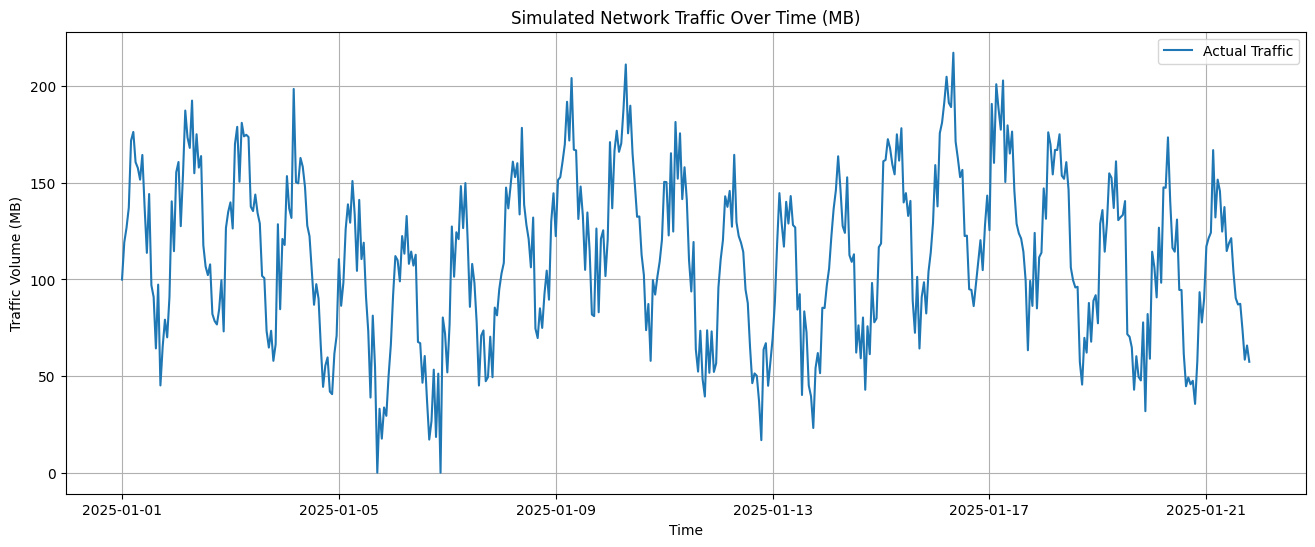

In [5]:
df = generate_traffic_data(2500)

plt.figure(figsize=(16,6))
plt.title('Simulated Network Traffic Over Time (MB)')
plt.plot(df.index[:500], df['Traffic_Volume_MB'][:500], label='Actual Traffic')
plt.xlabel('Time')
plt.ylabel('Traffic Volume (MB)')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
def preprocess_data(df, sequence_length=48):
    print("Preprocessing data...")
    dataset = df.values

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    train_size = int(len(scaled_data) * 0.8)
    train_data = scaled_data[:train_size, :]
    test_data = scaled_data[train_size - sequence_length:, :]

    def create_sequences(data, seq_length):
        X, y = [], []
        for i in range(seq_length, len(data)):
            X.append(data[i-seq_length:i, 0])
            y.append(data[i, 0])
        return np.array(X), np.array(y)

    X_train, y_train = create_sequences(train_data, sequence_length)
    X_test, y_test = create_sequences(test_data, sequence_length)

    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    return X_train, y_train, X_test, y_test, scaler, train_size

In [7]:
sequence_length = 48
X_train, y_train, X_test, y_test, scaler, train_size = preprocess_data(df, sequence_length)

Preprocessing data...


In [8]:
def build_lstm_model(input_shape):
    print("Building LSTM Model...")
    model = Sequential()

    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))

    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dropout(0.2))

    model.add(Dense(units=1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [9]:
model = build_lstm_model((X_train.shape[1], 1))
model.summary()

Building LSTM Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=15,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.0389 - val_loss: 0.0201
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0192 - val_loss: 0.0229
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0143 - val_loss: 0.0093
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0063 - val_loss: 0.0040
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0057 - val_loss: 0.0032
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0052 - val_loss: 0.0050
Epoch 7/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0051 - val_loss: 0.0033
Epoch 8/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0049 - val_loss: 0.0031
Epoch 9/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0044 - val_loss: 0.0032
Epoch 10/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0045 - val_loss: 0.0049
Epoch 11/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0046 - val_loss: 0.0029
Epoch 12/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0

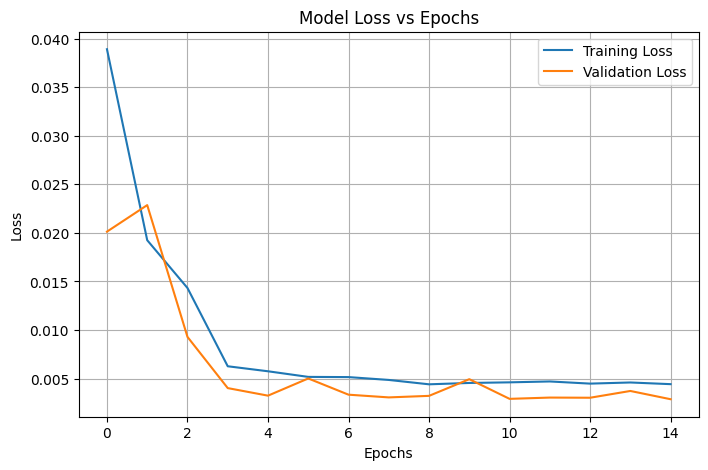

In [11]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
predictions_scaled = model.predict(X_test)
predictions = scaler.inverse_transform(predictions_scaled)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


In [13]:
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 13.449505942230548
Root Mean Squared Error (RMSE): 16.749574749998153


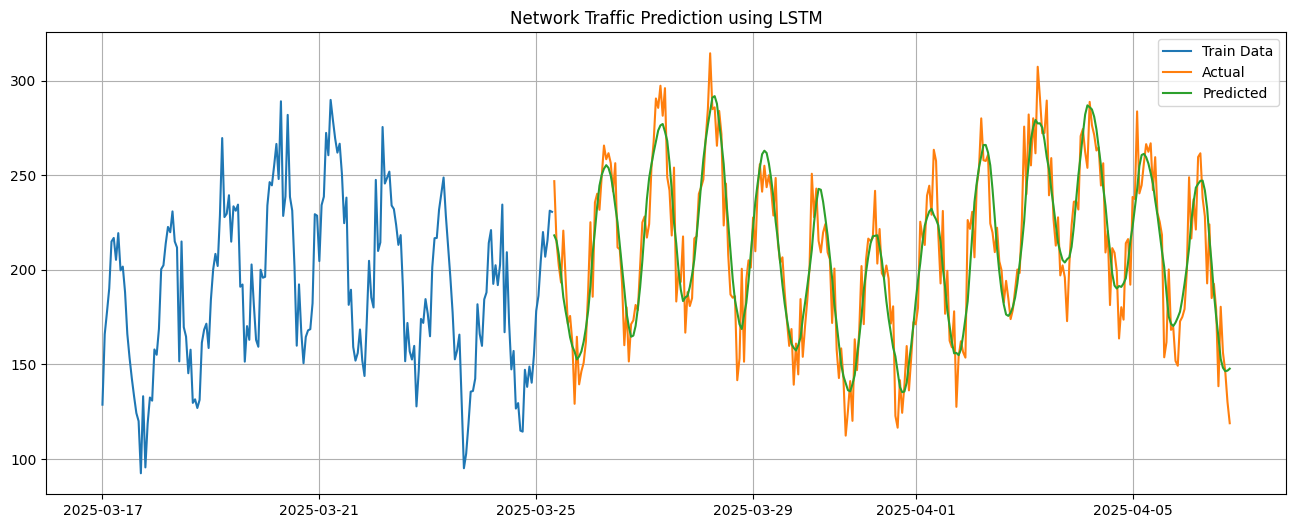

In [14]:
train = df[:train_size]
valid = df[train_size:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(16,6))
plt.title('Network Traffic Prediction using LSTM')

plt.plot(train.index[-200:], train['Traffic_Volume_MB'][-200:], label='Train Data')
plt.plot(valid.index[:300], valid['Traffic_Volume_MB'][:300], label='Actual')
plt.plot(valid.index[:300], valid['Predictions'][:300], label='Predicted')

plt.legend()
plt.grid(True)
plt.show()